 Dataset loaded successfully!

 Dataset Shape: (161, 14)

 First few rows:
   Product_id  Price  Sale  weight  resoloution  ppi  cpu core  cpu freq  \
0         203   2357    10   135.0          5.2  424         8      1.35   
1         880   1749    10   125.0          4.0  233         2      1.30   
2          40   1916    10   110.0          4.7  312         4      1.20   
3          99   1315    11   118.5          4.0  233         2      1.30   
4         880   1749    11   125.0          4.0  233         2      1.30   

   internal mem    ram  RearCam  Front_Cam  battery  thickness  
0          16.0  3.000    13.00        8.0     2610        7.4  
1           4.0  1.000     3.15        0.0     1700        9.9  
2           8.0  1.500    13.00        5.0     2000        7.6  
3           4.0  0.512     3.15        0.0     1400       11.0  
4           4.0  1.000     3.15        0.0     1700        9.9  

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries,

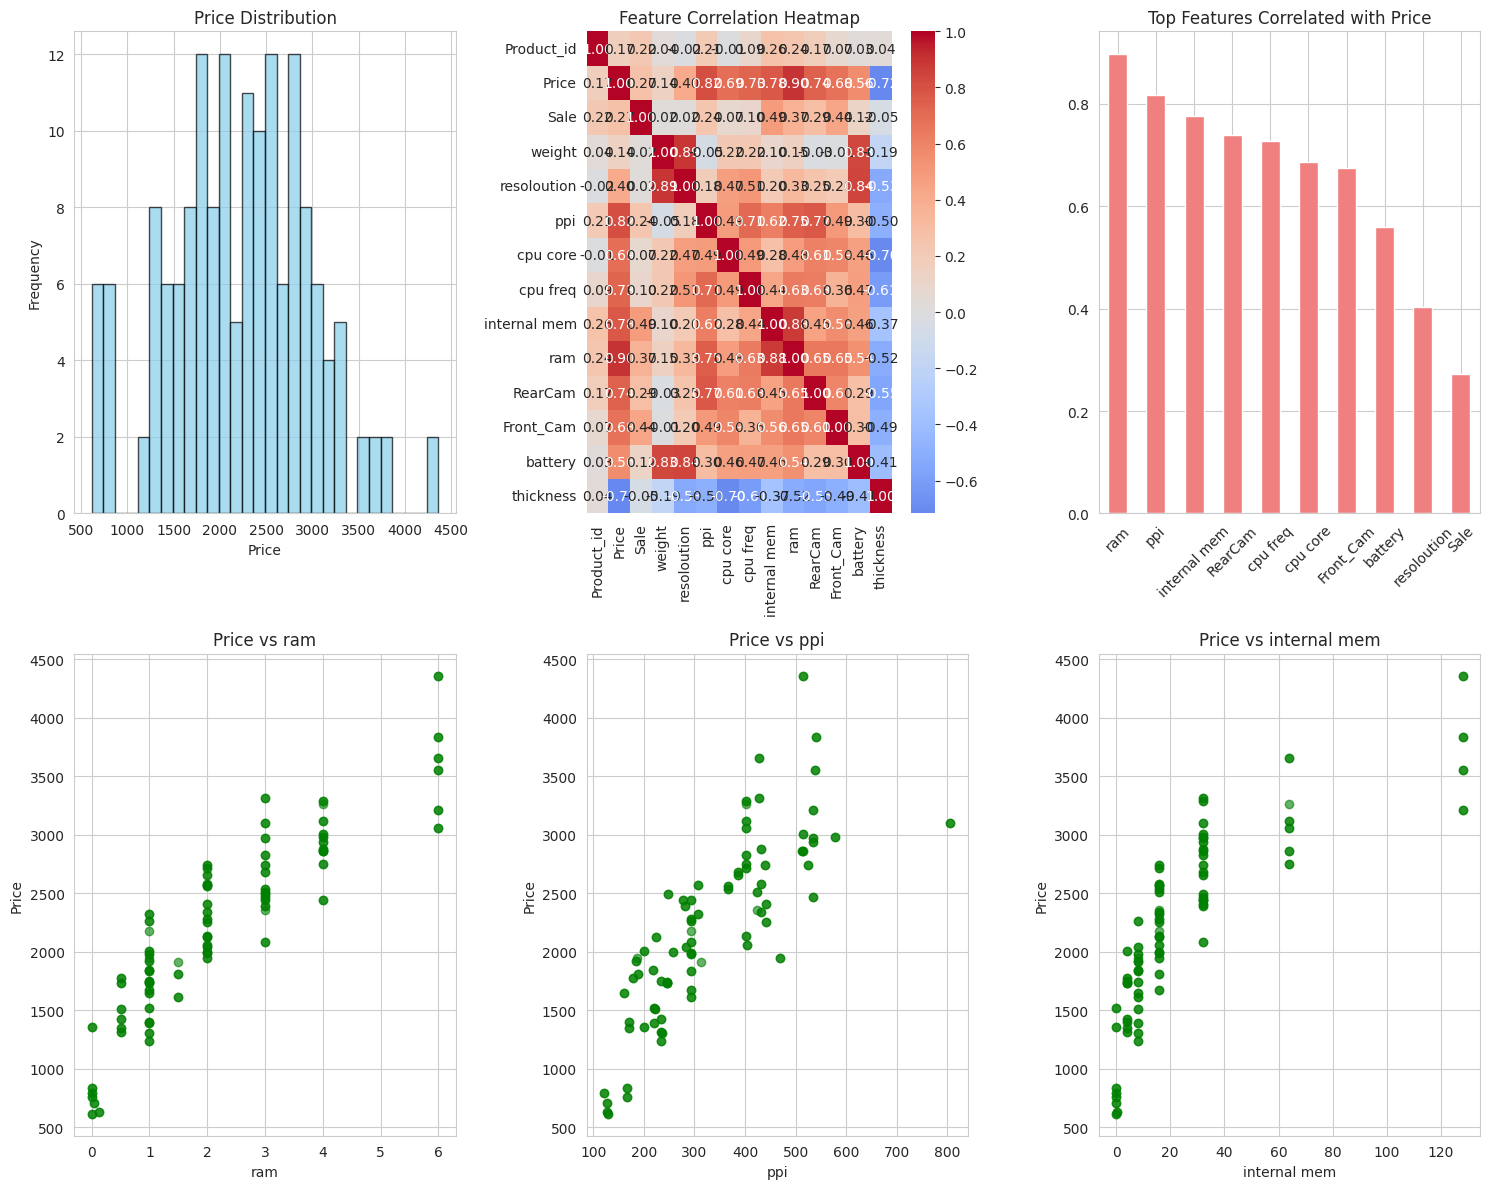


 Correlation with Price:
ram             0.896915
ppi             0.817614
internal mem    0.776738
RearCam         0.739538
cpu freq        0.727383
cpu core        0.686811
Front_Cam       0.675286
battery         0.559946
resoloution     0.404010
Sale            0.273263
Product_id      0.165136
weight          0.144555
thickness      -0.716773
Name: Price, dtype: float64

 Preparing data (test_size=0.2)...
 Features used: ['Sale', 'weight', 'resoloution', 'ppi', 'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam', 'battery', 'thickness']
 X shape: (161, 12), y shape: (161,)
 Data split completed:
   Training set: 128 samples
   Testing set: 33 samples

 Standardizing data...
 Data standardization completed!

 LINEAR REGRESSION IMPLEMENTATION

 1. CLOSED-FORM SOLUTION (NO REGULARIZATION)

 Closed-form solution (λ=0)...

 Closed-Form Solution Performance:
   MSE: 21880.49
   RMSE: 147.92
   MAE: 123.46
   R² Score: 0.9614

 2. GRADIENT DESCENT (NO REGULARIZATION)



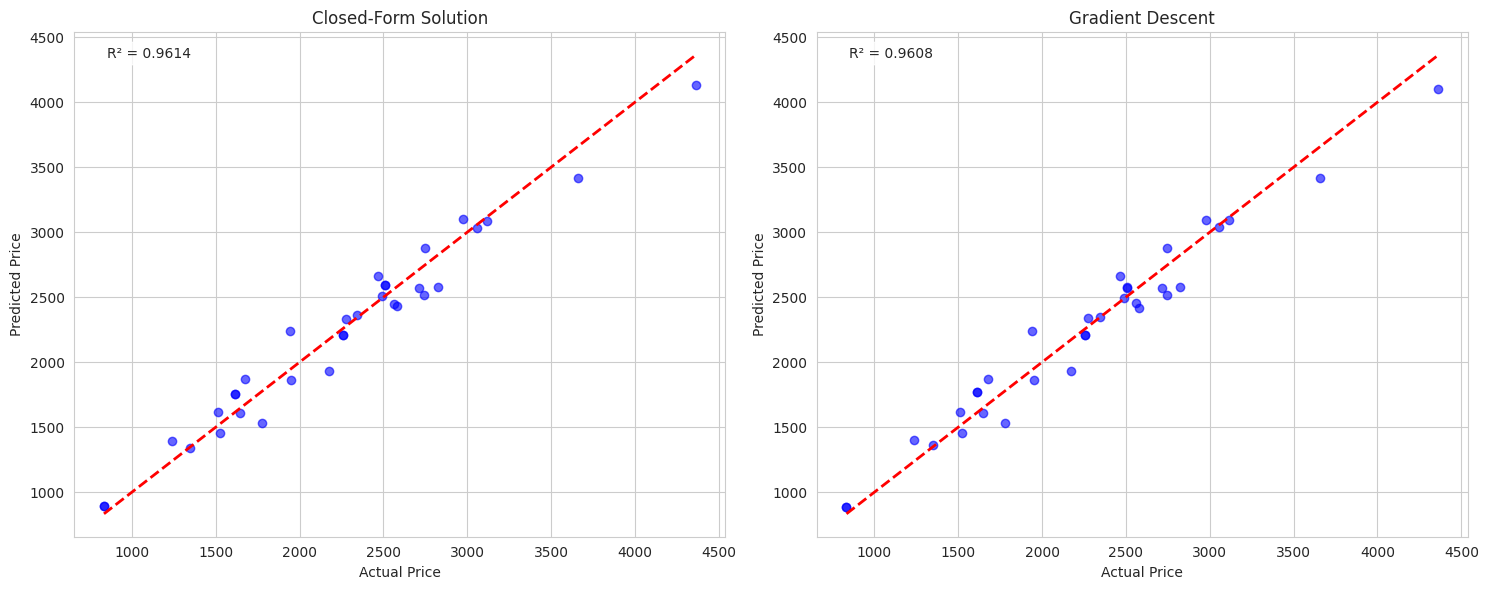

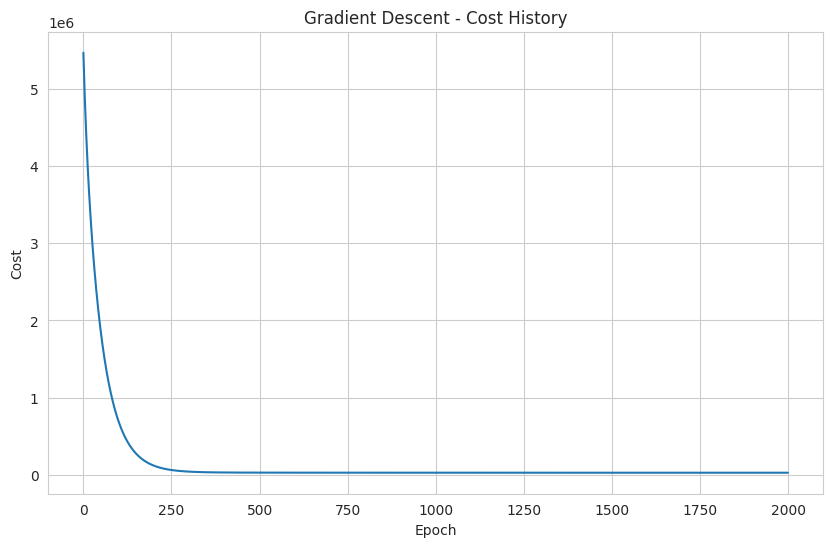


 4. RIDGE REGRESSION (L2 REGULARIZATION)

 Closed-form solution (λ=0)...

 Ridge (λ=0) Performance:
   MSE: 21880.49
   RMSE: 147.92
   MAE: 123.46
   R² Score: 0.9614

 Closed-form solution (λ=0.1)...

 Ridge (λ=0.1) Performance:
   MSE: 21913.59
   RMSE: 148.03
   MAE: 123.40
   R² Score: 0.9613

 Closed-form solution (λ=1)...

 Ridge (λ=1) Performance:
   MSE: 22206.73
   RMSE: 149.02
   MAE: 123.28
   R² Score: 0.9608

 Closed-form solution (λ=10)...

 Ridge (λ=10) Performance:
   MSE: 25227.66
   RMSE: 158.83
   MAE: 125.54
   R² Score: 0.9555

 Closed-form solution (λ=100)...

 Ridge (λ=100) Performance:
   MSE: 52260.93
   RMSE: 228.61
   MAE: 172.23
   R² Score: 0.9078


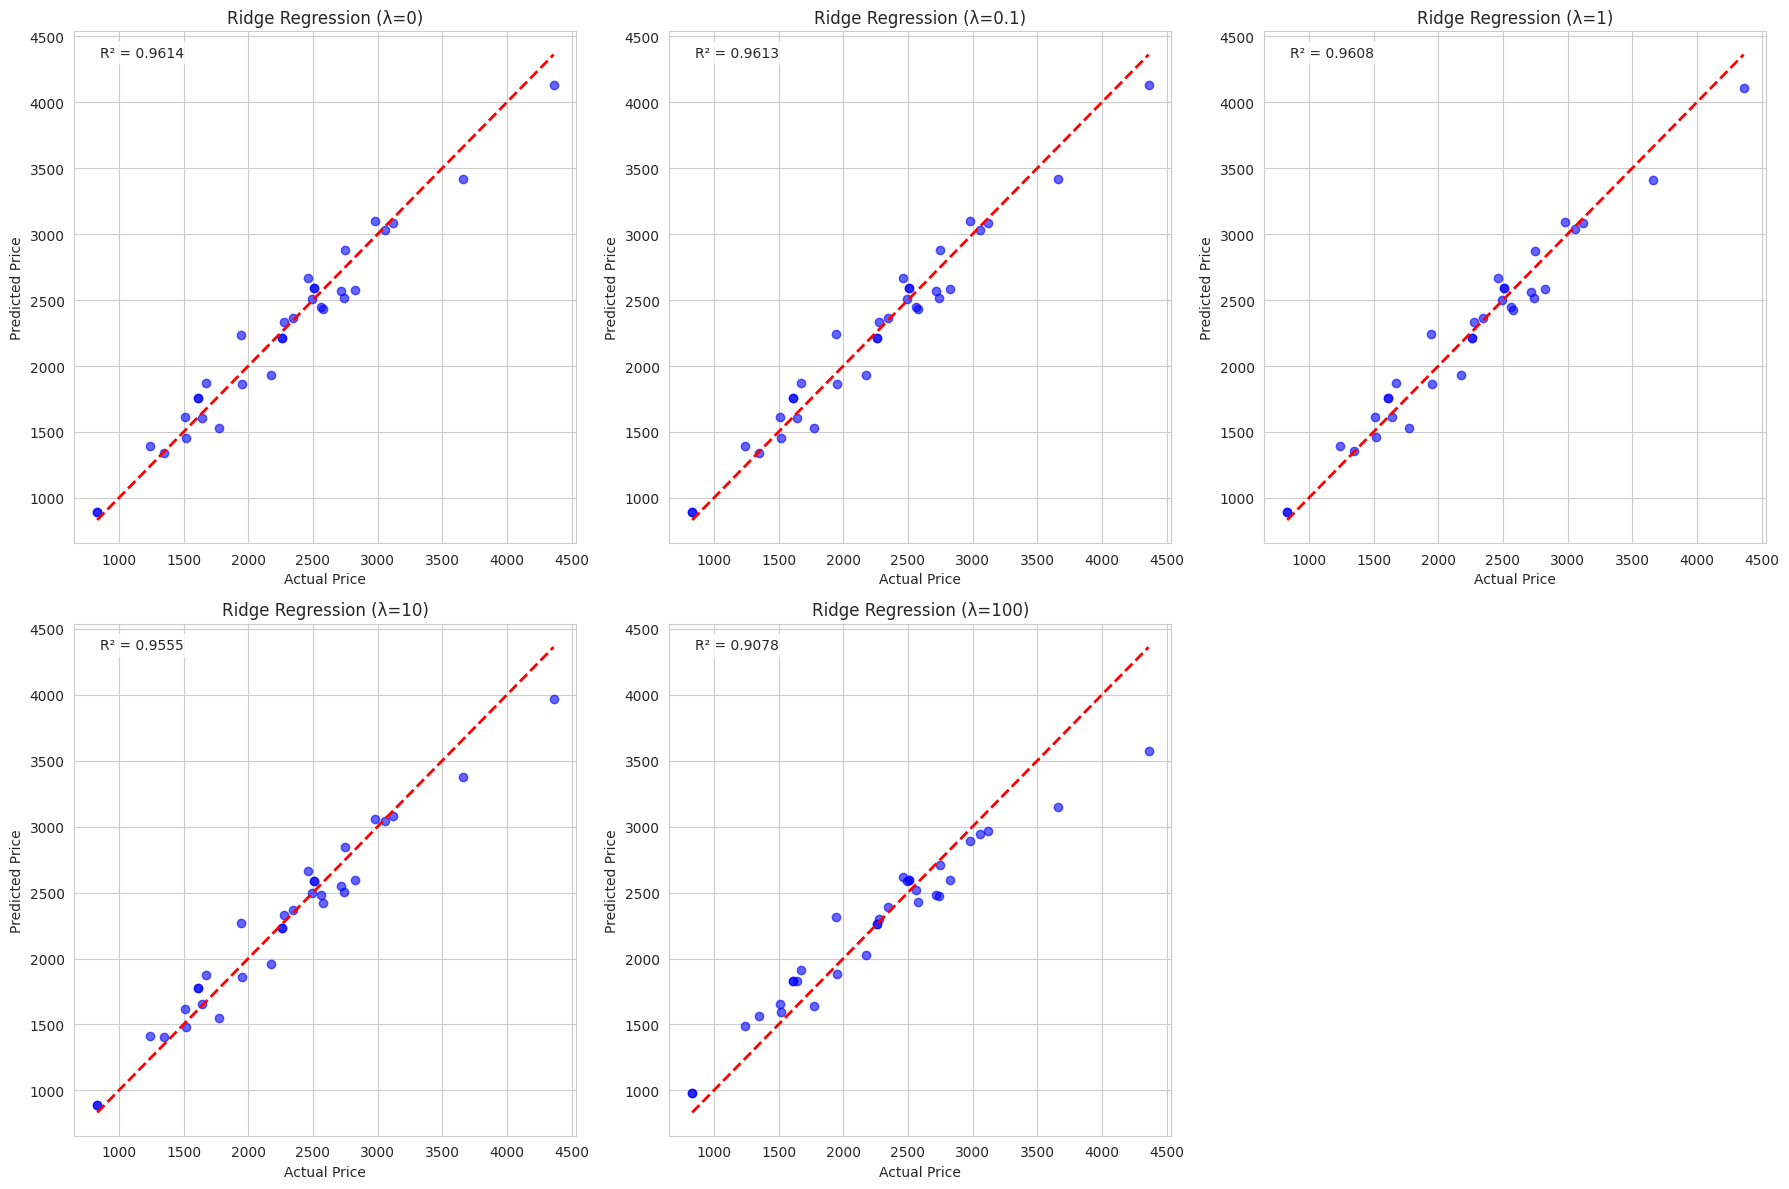


 5. COMPARISON: WITH VS WITHOUT STANDARDIZATION

 Closed-form solution (λ=1)...

 Ridge without Standardization Performance:
   MSE: 21903.47
   RMSE: 148.00
   MAE: 123.13
   R² Score: 0.9614

 Performance Comparison (λ=1):
      Without Standardization  With Standardization
MSE              21903.468725          22206.728003
RMSE               147.998205            149.019220
MAE                123.125358            123.284336
R2                   0.961362              0.960827

 6. PERFORMANCE ACROSS DIFFERENT λ VALUES


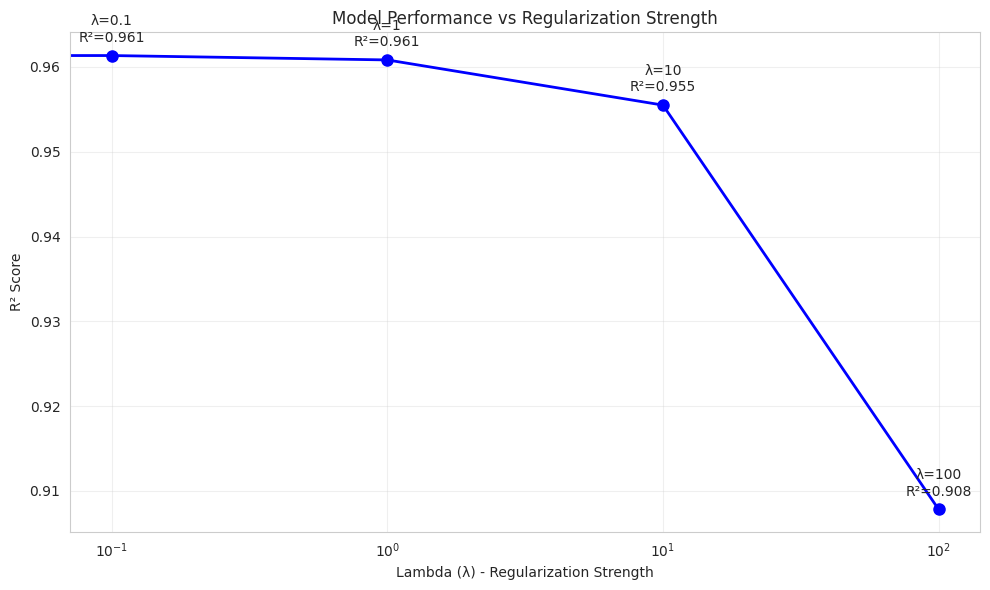


 7. FEATURE IMPORTANCE ANALYSIS

 Closed-form solution (λ=1)...

 Ridge Regression Feature Importance - Feature Importance:
         Feature      Weight  Raw_Weight
6   internal mem  165.139565  165.139565
7            ram  164.373432  164.373432
11     thickness  154.931283 -154.931283
10       battery  154.287748  154.287748
3            ppi  152.757885  152.757885
4       cpu core  122.873598  122.873598
2    resoloution   78.962018  -78.962018
5       cpu freq   75.474715   75.474715
1         weight   53.191444  -53.191444
9      Front_Cam   33.236574   33.236574
0           Sale   31.394938  -31.394938
8        RearCam   24.552476   24.552476


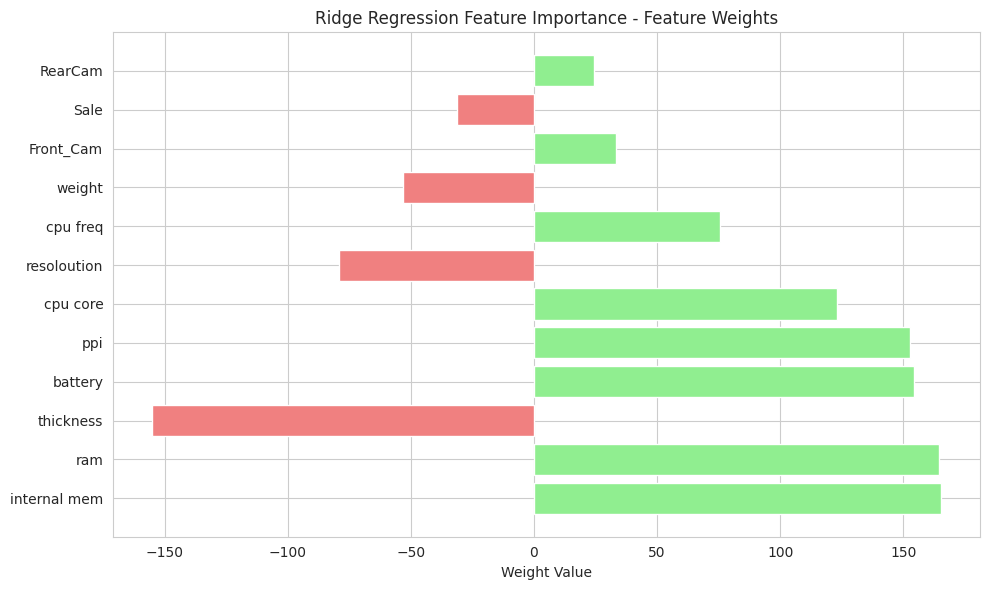


 FINAL SUMMARY

 Model Comparison Summary:
                           MSE        RMSE         MAE        R2
Closed-Form       21880.491702  147.920559  123.464533  0.961403
Gradient Descent  22245.311956  149.148624  122.472597  0.960759

 Key Insights:
• Best performing model: Closed-Form (R² = 0.9614)
• Most important feature: internal mem
• Number of features used: 12
• Dataset size: (161, 14)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

class MobilePhonePricePredictor:
    def __init__(self):
        self.data = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.scaler = None
        self.feature_names = None
        self.X_train_scaled = None # Add scaled attributes to the class
        self.X_test_scaled = None

    def load_and_preprocess_data(self):
        """Load and preprocess the Cellphone.csv dataset"""
        # Load the dataset
        try:
            self.data = pd.read_csv('Cellphone.csv')
            print(" Dataset loaded successfully!")
        except:
            print(" Error loading dataset. Please check if 'Cellphone.csv' is uploaded.")
            return False

        # Display basic info
        print(f"\n Dataset Shape: {self.data.shape}")
        print(f"\n First few rows:")
        print(self.data.head())

        print(f"\n Dataset Info:")
        print(self.data.info())

        print(f"\n Basic Statistics:")
        print(self.data.describe())

        print(f"\n Checking for missing values:")
        print(self.data.isnull().sum())

        # Handle missing values if any
        if self.data.isnull().sum().sum() > 0:
            print("\n Handling missing values...")
            # Fill numerical columns with median
            numerical_cols = self.data.select_dtypes(include=[np.number]).columns
            self.data[numerical_cols] = self.data[numerical_cols].fillna(self.data[numerical_cols].median())
            print(" Missing values handled!")

        return True

    def perform_eda(self):
        """Perform Exploratory Data Analysis"""
        print("\n" + "="*50)
        print(" EXPLORATORY DATA ANALYSIS")
        print("="*50)

        # 1. Price distribution
        plt.figure(figsize=(15, 12))

        plt.subplot(2, 3, 1)
        plt.hist(self.data['Price'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        plt.title('Price Distribution')
        plt.xlabel('Price')
        plt.ylabel('Frequency')

        # 2. Correlation heatmap
        plt.subplot(2, 3, 2)
        numeric_data = self.data.select_dtypes(include=[np.number])
        correlation_matrix = numeric_data.corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
        plt.title('Feature Correlation Heatmap')
        plt.tight_layout()

        # 3. Top features correlated with price
        plt.subplot(2, 3, 3)
        price_correlations = correlation_matrix['Price'].drop('Price').sort_values(ascending=False)
        price_correlations.head(10).plot(kind='bar', color='lightcoral')
        plt.title('Top Features Correlated with Price')
        plt.xticks(rotation=45)
        plt.tight_layout()

        # 4. Scatter plots for top correlated features
        top_features = price_correlations.head(3).index
        for i, feature in enumerate(top_features, 4):
            plt.subplot(2, 3, i)
            plt.scatter(self.data[feature], self.data['Price'], alpha=0.6, color='green')
            plt.xlabel(feature)
            plt.ylabel('Price')
            plt.title(f'Price vs {feature}')

        plt.tight_layout()
        plt.show()

        # Display correlation with price
        print("\n Correlation with Price:")
        print(price_correlations)

    def prepare_data(self, test_size=0.2):
        """Prepare data for training and testing"""
        print(f"\n Preparing data (test_size={test_size})...")

        # Select features - exclude Product_id and use all other numerical features
        exclude_cols = ['Product_id', 'Price']
        self.feature_names = [col for col in self.data.columns if col not in exclude_cols]

        X = self.data[self.feature_names]
        y = self.data['Price']

        print(f" Features used: {list(self.feature_names)}")
        print(f" X shape: {X.shape}, y shape: {y.shape}")

        # Split the data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )

        print(f" Data split completed:")
        print(f"   Training set: {self.X_train.shape[0]} samples")
        print(f"   Testing set: {self.X_test.shape[0]} samples")

    def standardize_data(self):
        """Standardize the features"""
        print("\n Standardizing data...")
        self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)
        print(" Data standardization completed!")

    def closed_form_solution(self, X_train, y_train, X_test, lambda_reg=0):
        """Implement closed-form solution for linear regression"""
        print(f"\n Closed-form solution (λ={lambda_reg})...")

        # Add bias term (column of ones)
        X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
        X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

        if lambda_reg == 0:
            # Standard normal equation: w = (X^T X)^(-1) X^T y
            # Use pinv for robustness
            w = np.linalg.pinv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train
        else:
            # Ridge regression: w = (X^T X + λI)^(-1) X^T y
            I = np.eye(X_train_bias.shape[1])
            I[0, 0] = 0  # Don't regularize bias term
            w = np.linalg.pinv(X_train_bias.T @ X_train_bias + lambda_reg * I) @ X_train_bias.T @ y_train

        # Make predictions
        y_pred_train = X_train_bias @ w
        y_pred_test = X_test_bias @ w

        return w, y_pred_train, y_pred_test

    def gradient_descent(self, X_train, y_train, X_test, learning_rate=0.01, epochs=1000, lambda_reg=0):
        """Implement gradient descent for linear regression"""
        print(f"\n Gradient Descent (lr={learning_rate}, epochs={epochs}, λ={lambda_reg})...")

        # Add bias term
        X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
        X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]


        # Initialize weights
        w = np.zeros(X_train_bias.shape[1])
        n_samples = X_train_bias.shape[0]

        # Store cost history
        cost_history = []

        for epoch in range(epochs):
            # Predictions
            y_pred = X_train_bias @ w

            # Compute gradients
            error = y_pred - y_train
            gradient = (X_train_bias.T @ error) / n_samples

            # Add regularization term (except for bias)
            if lambda_reg > 0:
                reg_term = lambda_reg * w.copy()
                reg_term[0] = 0  # Don't regularize bias
                gradient += reg_term / n_samples

            # Update weights
            w -= learning_rate * gradient

            # Compute cost
            cost = np.mean(error ** 2)
            if lambda_reg > 0:
                cost += lambda_reg * np.sum(w[1:] ** 2) / n_samples
            cost_history.append(cost)

            if epoch % 200 == 0:
                print(f"   Epoch {epoch}: Cost = {cost:.4f}")

        # Final predictions
        y_pred_train = X_train_bias @ w
        y_pred_test = X_test_bias @ w

        return w, y_pred_train, y_pred_test, cost_history

    def evaluate_model(self, y_true, y_pred, model_name):
        """Evaluate model performance"""
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        print(f"\n {model_name} Performance:")
        print(f"   MSE: {mse:.2f}")
        print(f"   RMSE: {rmse:.2f}")
        print(f"   MAE: {mae:.2f}")
        print(f"   R² Score: {r2:.4f}")

        return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

    def plot_predictions_vs_actual(self, y_true, y_pred, title, ax):
        """Plot predicted vs actual values"""
        ax.scatter(y_true, y_pred, alpha=0.6, color='blue')
        ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
        ax.set_xlabel('Actual Price')
        ax.set_ylabel('Predicted Price')
        ax.set_title(title)

        # Add R² to plot
        r2 = r2_score(y_true, y_pred)
        ax.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax.transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    def analyze_feature_importance(self, weights, feature_names, title):
        """Analyze and plot feature importance from weights"""
        print(f"\n {title} - Feature Importance:")

        # Exclude bias term
        feature_weights = weights[1:]

        # Create feature importance dataframe
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Weight': np.abs(feature_weights),
            'Raw_Weight': feature_weights
        }).sort_values('Weight', ascending=False)

        print(importance_df)

        # Plot feature importance
        plt.figure(figsize=(10, 6))
        colors = ['lightgreen' if x > 0 else 'lightcoral' for x in importance_df['Raw_Weight']]
        plt.barh(importance_df['Feature'], importance_df['Raw_Weight'], color=colors)
        plt.xlabel('Weight Value')
        plt.title(f'{title} - Feature Weights')
        plt.tight_layout()
        plt.show()

        return importance_df

# Main execution
def main():
    # Initialize predictor
    predictor = MobilePhonePricePredictor()

    # 1. Load and preprocess data
    if not predictor.load_and_preprocess_data():
        return

    # 2. Perform EDA
    predictor.perform_eda()

    # 3. Prepare data
    predictor.prepare_data(test_size=0.2)

    # Standardize data before running Gradient Descent
    predictor.standardize_data()


    print("\n" + "="*60)
    print(" LINEAR REGRESSION IMPLEMENTATION")
    print("="*60)

    # Store results for comparison
    results = {}

    # 1.1 Closed-form solution without regularization
    print("\n" + " 1. CLOSED-FORM SOLUTION (NO REGULARIZATION)")
    # Use original data for closed-form without regularization
    w_cf, y_pred_train_cf, y_pred_test_cf = predictor.closed_form_solution(
        predictor.X_train.values, predictor.y_train.values,
        predictor.X_test.values, lambda_reg=0
    )
    results['Closed-Form'] = predictor.evaluate_model(predictor.y_test, y_pred_test_cf, "Closed-Form Solution")

    # 1.2 Gradient descent without regularization
    print("\n" + " 2. GRADIENT DESCENT (NO REGULARIZATION)")
    # Use standardized data for Gradient Descent
    w_gd, y_pred_train_gd, y_pred_test_gd, cost_history = predictor.gradient_descent(
        predictor.X_train_scaled, predictor.y_train.values,
        predictor.X_test_scaled, learning_rate=0.01, epochs=2000, lambda_reg=0
    )
    results['Gradient Descent'] = predictor.evaluate_model(predictor.y_test, y_pred_test_gd, "Gradient Descent")

    # Plot predictions for (1) and (2)
    print("\n" + " 3. PREDICTED VS ACTUAL PLOTS")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    predictor.plot_predictions_vs_actual(predictor.y_test, y_pred_test_cf,
                                       "Closed-Form Solution", ax1)
    predictor.plot_predictions_vs_actual(predictor.y_test, y_pred_test_gd,
                                       "Gradient Descent", ax2)
    plt.tight_layout()
    plt.show()

    # Plot cost history for gradient descent
    plt.figure(figsize=(10, 6))
    plt.plot(cost_history)
    plt.title('Gradient Descent - Cost History')
    plt.xlabel('Epoch')
    plt.ylabel('Cost')
    plt.grid(True)
    plt.show()

    # 4. With L2 Regularization (Ridge Regression)
    print("\n" + "="*50)
    print(" 4. RIDGE REGRESSION (L2 REGULARIZATION)")
    print("="*50)

    # Standardize data for regularization - already done above

    lambda_values = [0, 0.1, 1, 10, 100]
    ridge_results = {}

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, lambda_val in enumerate(lambda_values):
        # Closed-form with regularization
        w_ridge, y_pred_train_ridge, y_pred_test_ridge = predictor.closed_form_solution(
            predictor.X_train_scaled, predictor.y_train.values,
            predictor.X_test_scaled, lambda_reg=lambda_val
        )

        # Evaluate
        ridge_results[lambda_val] = predictor.evaluate_model(
            predictor.y_test, y_pred_test_ridge, f"Ridge (λ={lambda_val})"
        )

        # Plot
        if i < len(axes):
            predictor.plot_predictions_vs_actual(
                predictor.y_test, y_pred_test_ridge,
                f'Ridge Regression (λ={lambda_val})', axes[i]
            )

    # Remove empty subplots
    for i in range(len(lambda_values), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

    # 5. Compare with and without standardization
    print("\n" + "="*50)
    print(" 5. COMPARISON: WITH VS WITHOUT STANDARDIZATION")
    print("="*50)

    # Without standardization
    w_ridge_no_std, _, y_pred_test_no_std = predictor.closed_form_solution(
        predictor.X_train.values, predictor.y_train.values,
        predictor.X_test.values, lambda_reg=1
    )
    results_no_std = predictor.evaluate_model(predictor.y_test, y_pred_test_no_std, "Ridge without Standardization")

    # With standardization (already computed)
    results_std = ridge_results[1]

    comparison_df = pd.DataFrame({
        'Without Standardization': results_no_std,
        'With Standardization': results_std
    })
    print("\n Performance Comparison (λ=1):")
    print(comparison_df)

    # 6. Plot for different lambda values
    print("\n" + " 6. PERFORMANCE ACROSS DIFFERENT λ VALUES")

    # Extract R² scores for different lambda values
    lambda_r2 = {lam: result['R2'] for lam, result in ridge_results.items()}

    plt.figure(figsize=(10, 6))
    plt.semilogx(list(lambda_r2.keys()), list(lambda_r2.values()), 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Lambda (λ) - Regularization Strength')
    plt.ylabel('R² Score')
    plt.title('Model Performance vs Regularization Strength')
    plt.grid(True, alpha=0.3)

    for lam, r2 in lambda_r2.items():
        plt.annotate(f'λ={lam}\nR²={r2:.3f}', (lam, r2),
                    textcoords="offset points", xytext=(0,10), ha='center')

    plt.tight_layout()
    plt.show()

    # 7. Analyze feature importance
    print("\n" + "="*50)
    print(" 7. FEATURE IMPORTANCE ANALYSIS")
    print("="*50)

    # Get weights from ridge regression with moderate regularization
    w_ridge_final, _, _ = predictor.closed_form_solution(
        predictor.X_train_scaled, predictor.y_train.values,
        predictor.X_test_scaled, lambda_reg=1
    )

    importance_df = predictor.analyze_feature_importance(
        w_ridge_final, predictor.feature_names, "Ridge Regression Feature Importance"
    )

    # Final summary
    print("\n" + "="*60)
    print(" FINAL SUMMARY")
    print("="*60)

    summary_df = pd.DataFrame(results).T
    print("\n Model Comparison Summary:")
    print(summary_df)

    print(f"• Best performing model: {summary_df['R2'].idxmax()} (R² = {summary_df['R2'].max():.4f})")
    print(f"• Most important feature: {importance_df.iloc[0]['Feature']}")
    print(f"• Number of features used: {len(predictor.feature_names)}")
    print(f"• Dataset size: {predictor.data.shape}")

# Run the main function
if __name__ == "__main__":
    main()

 Dataset loaded successfully!

 Dataset Shape: (1372, 5)

 First few rows:
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

 Class Distribution:
class
0    762
1    610
Name: count, dtype: int64
   Class 0: 762 samples
   Class 1: 610 samples

 Basic Statistics:
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000


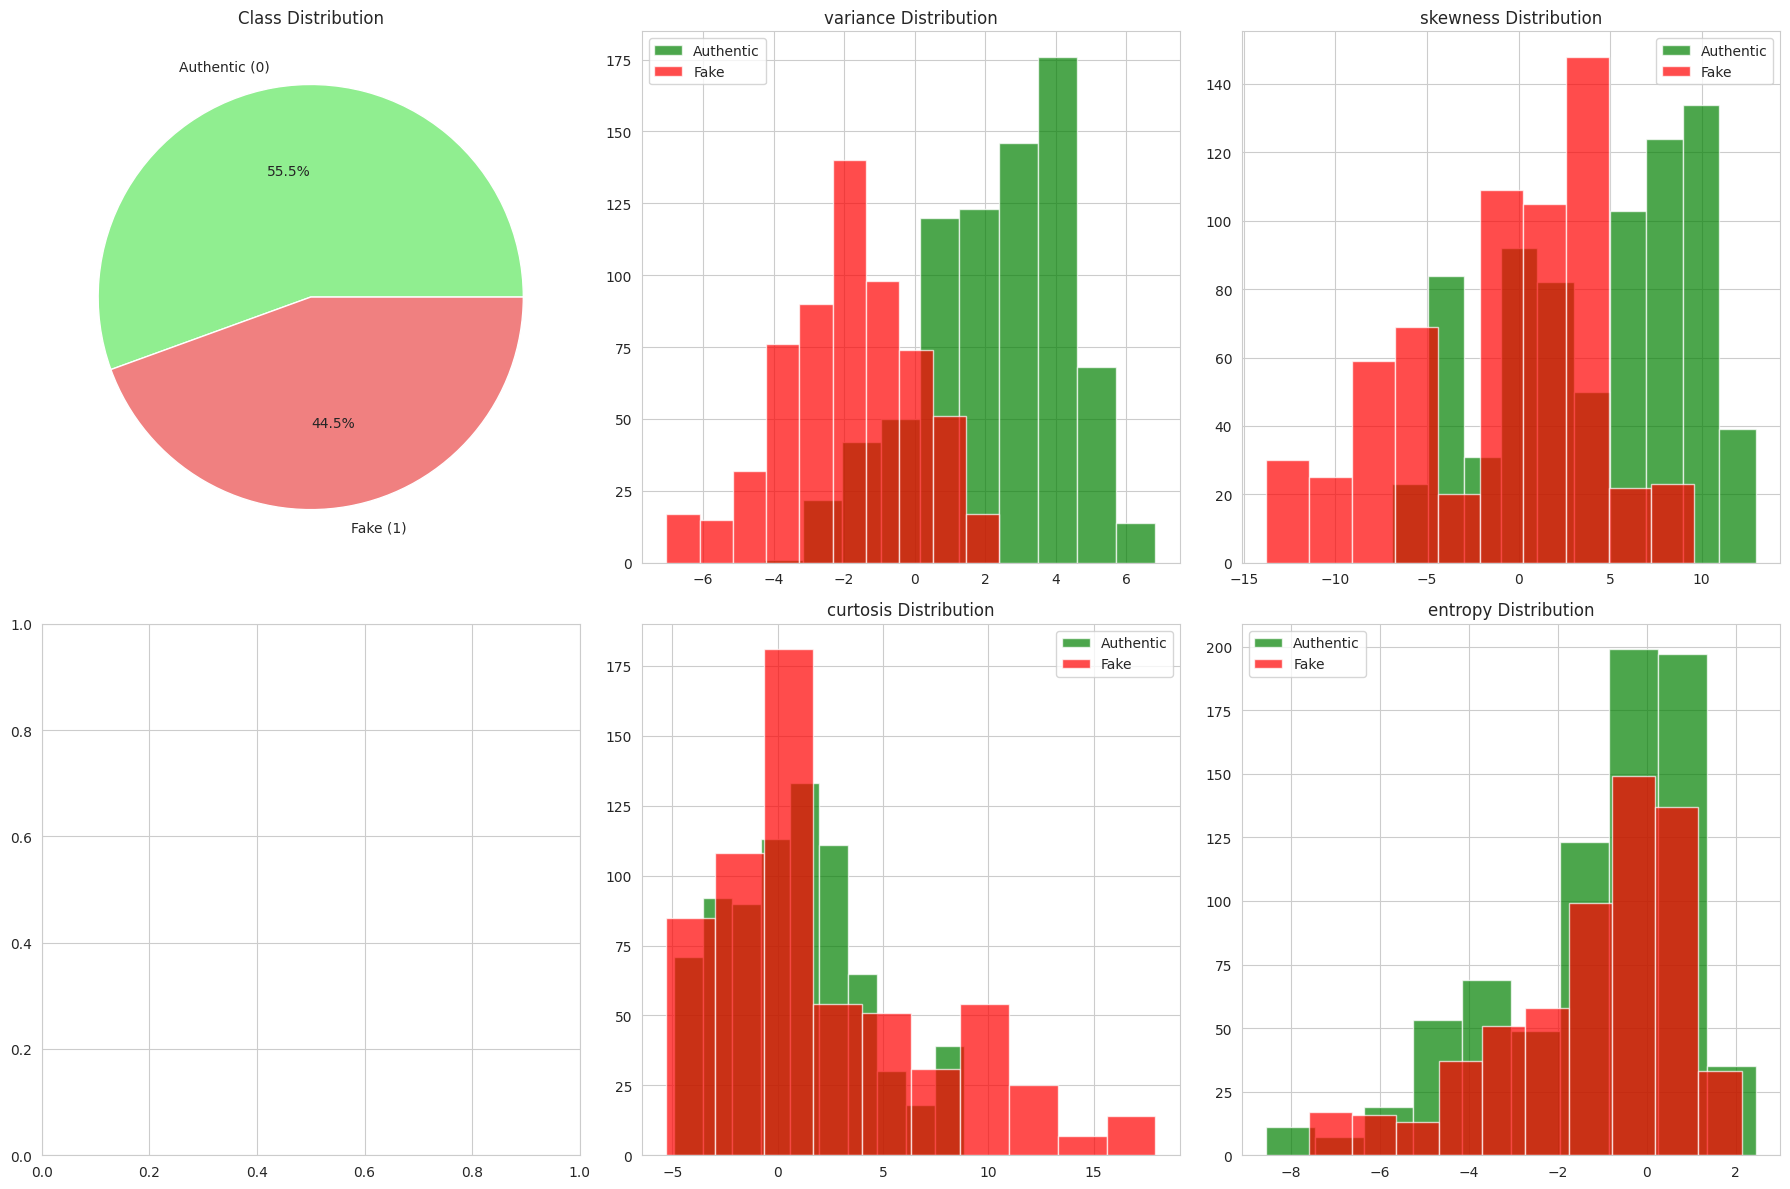

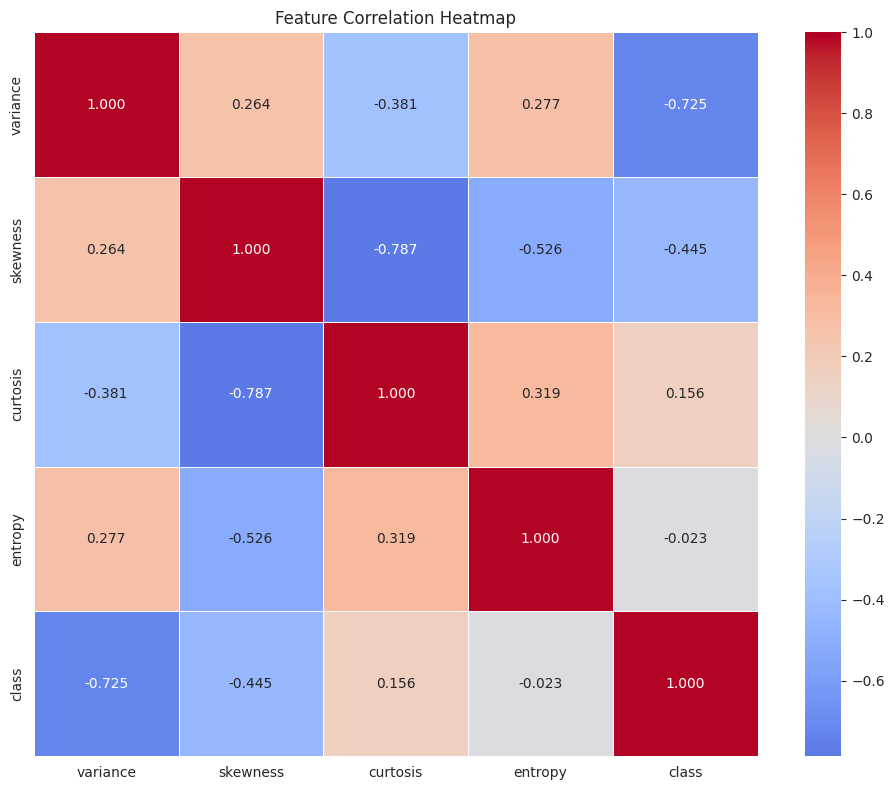


 Feature Correlations with Target:
   variance: 0.7248
   skewness: 0.4447
   curtosis: 0.1559
   entropy: 0.0234

 Splitting data (test_size=0.3)...
 Data split completed:
   Training set: 960 samples
   Testing set: 412 samples
   Training class distribution: (array([0, 1]), array([533, 427]))
   Testing class distribution: (array([0, 1]), array([229, 183]))

 2. REGULARIZATION ANALYSIS

 Training with λ = 0
   Training Accuracy: 0.9885
   Testing Accuracy: 0.9879
   Weight magnitudes: [20.0736 22.6444 21.0289  1.5554]

 Training with λ = 0.001
   Training Accuracy: 0.9885
   Testing Accuracy: 0.9879
   Weight magnitudes: [18.5995 21.0285 19.498   1.3878]

 Training with λ = 0.01
   Training Accuracy: 0.9896
   Testing Accuracy: 0.9903
   Weight magnitudes: [13.4095 15.3335 14.0982  0.7881]

 Training with λ = 0.1
   Training Accuracy: 0.9917
   Testing Accuracy: 0.9903
   Weight magnitudes: [7.7062 8.7423 7.9723 0.0945]

 Training with λ = 1
   Training Accuracy: 0.9833
   Testing 

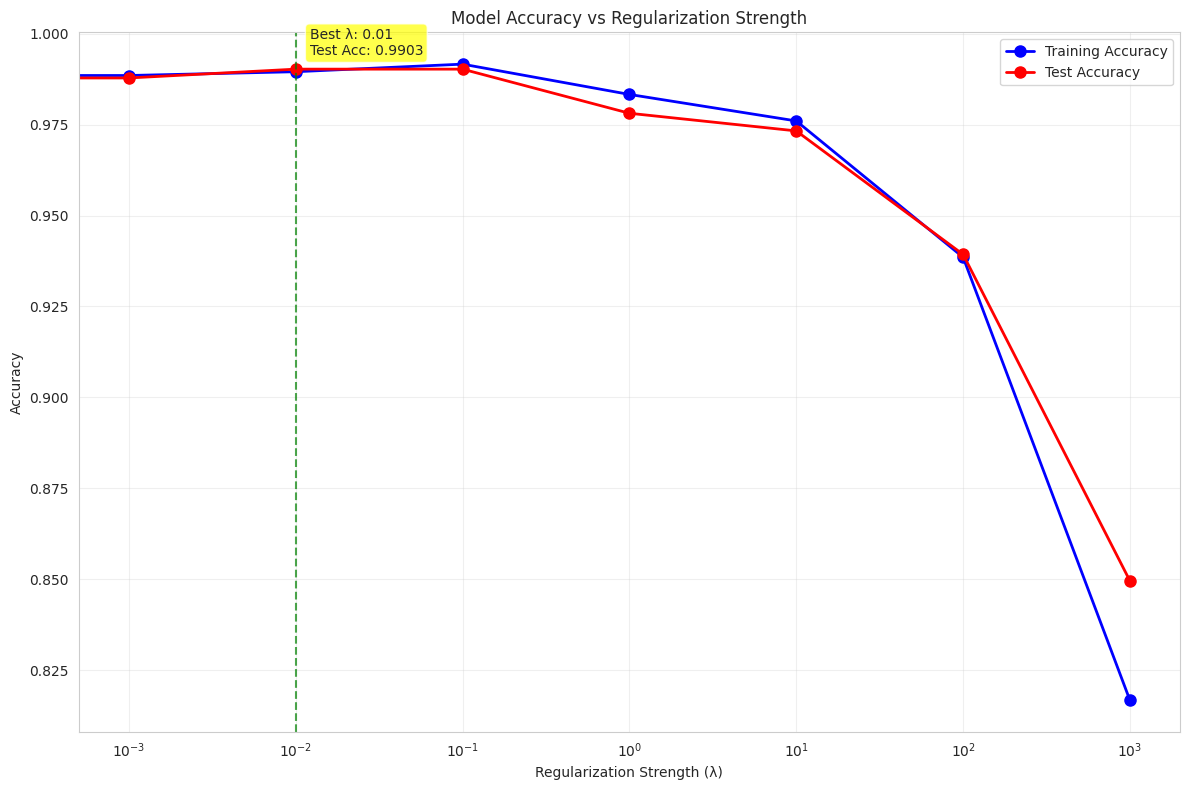


 Best performing model:
   λ = 0.01, Test Accuracy = 0.9903

 4. 3D VISUALIZATION
 Selected features for 3D visualization: ['variance', 'skewness', 'curtosis']


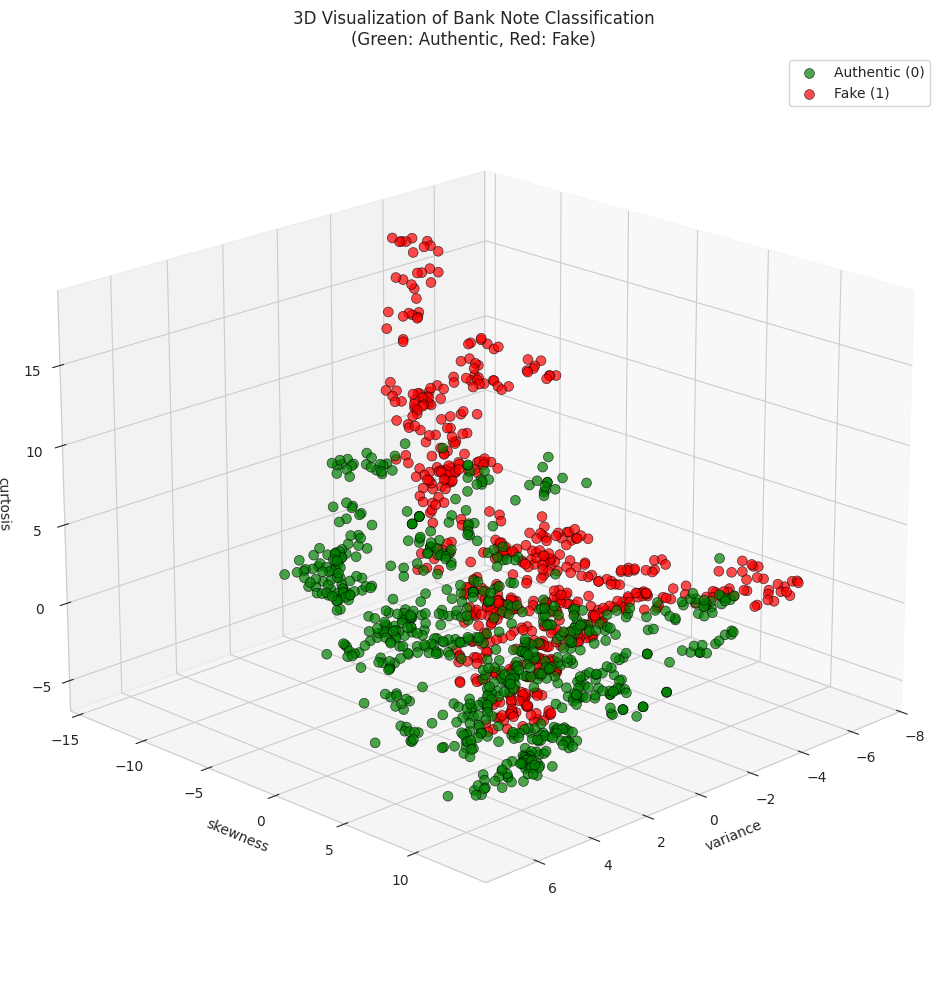

 3D visualization completed!

 5. OUTLIER INJECTION ANALYSIS
 Injecting outliers...
   Contamination rate: 0.15
   Shift magnitude: 2.5 standard deviations
   Number of outliers injected: 144
   Number of label flips: 43

 6. OUTLIER IMPACT ANALYSIS

 Training on CLEAN data...
 Clean data - Test Accuracy: 0.9782

 Training on CONTAMINATED data...
 Contaminated data - Test Accuracy: 0.9563

 IMPACT ANALYSIS:
   Accuracy Drop: 0.0218
   Percentage Drop: 2.23%

 Weight Changes due to Outliers:
   variance: 2.3323
   skewness: 3.2793
   curtosis: 3.0951
   entropy: 0.0755


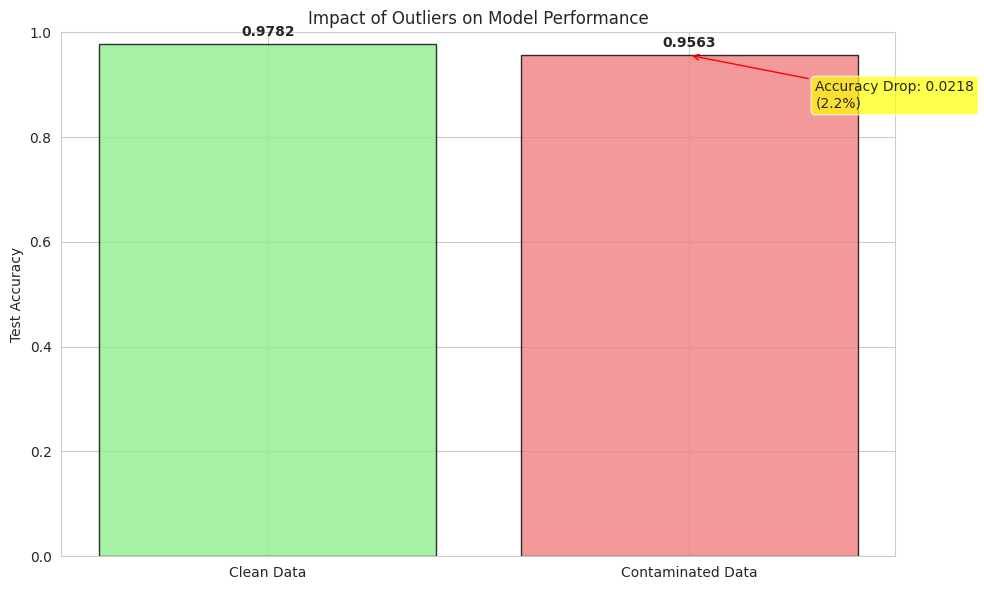


 TECHNICAL ANALYSIS:
   Model shows GOOD robustness to outliers
   Regularization is effectively controlling overfitting

 LINEAR CLASSIFICATION ANALYSIS COMPLETED!


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set style for professional visualizations
plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

class BankNoteClassifier:
    def __init__(self):
        self.data = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.scaler = StandardScaler()
        self.feature_names = ['variance', 'skewness', 'curtosis', 'entropy']

    def load_data(self):
        """Load Bank Note Authentication dataset"""
        try:
            self.data = pd.read_csv('BankNote_Authentication.csv')
            print(" Dataset loaded successfully!")
        except:
            print(" Dataset not found. Please ensure 'BankNote_Authentication.csv' is uploaded.")
            return False

        print(f"\n Dataset Shape: {self.data.shape}")
        print(f"\n First few rows:")
        print(self.data.head())

        print(f"\n Class Distribution:")
        print(self.data['class'].value_counts())
        print(f"   Class 0: {self.data['class'].value_counts()[0]} samples")
        print(f"   Class 1: {self.data['class'].value_counts()[1]} samples")

        print(f"\n Basic Statistics:")
        print(self.data.describe())

        return True

    def exploratory_analysis(self):
        """Perform comprehensive exploratory data analysis"""
        print("\n" + "="*50)
        print(" EXPLORATORY DATA ANALYSIS")
        print("="*50)

        # Create comprehensive EDA plots
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # 1. Class distribution
        axes[0,0].pie(self.data['class'].value_counts(), labels=['Authentic (0)', 'Fake (1)'],
                     autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
        axes[0,0].set_title('Class Distribution')

        # 2. Feature distributions by class
        for i, feature in enumerate(self.feature_names[:4]):
            row, col = i//2, i%2
            if row < 2 and col < 2:
                self.data[self.data['class'] == 0][feature].hist(alpha=0.7, label='Authentic', ax=axes[row, col+1], color='green')
                self.data[self.data['class'] == 1][feature].hist(alpha=0.7, label='Fake', ax=axes[row, col+1], color='red')
                axes[row, col+1].set_title(f'{feature} Distribution')
                axes[row, col+1].legend()

        plt.tight_layout()
        plt.show()

        # 3. Correlation heatmap
        plt.figure(figsize=(10, 8))
        correlation_matrix = self.data.corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                   square=True, fmt='.3f', linewidths=0.5)
        plt.title('Feature Correlation Heatmap')
        plt.tight_layout()
        plt.show()

        # 4. Feature importance analysis
        print("\n Feature Correlations with Target:")
        feature_correlations = correlation_matrix['class'].drop('class').abs().sort_values(ascending=False)
        for feature, corr in feature_correlations.items():
            print(f"   {feature}: {corr:.4f}")

    def split_data(self, test_size=0.3):
        """1. Divide dataset into train and test sets"""
        print(f"\n Splitting data (test_size={test_size})...")

        X = self.data[self.feature_names]
        y = self.data['class']

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )

        print(f" Data split completed:")
        print(f"   Training set: {self.X_train.shape[0]} samples")
        print(f"   Testing set: {self.X_test.shape[0]} samples")
        print(f"   Training class distribution: {np.unique(self.y_train, return_counts=True)}")
        print(f"   Testing class distribution: {np.unique(self.y_test, return_counts=True)}")

        # Standardize features
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

    def train_with_regularization(self, lambda_values):
        """2. Fit classification model with and without L2 regularization"""
        print("\n" + "="*50)
        print(" 2. REGULARIZATION ANALYSIS")
        print("="*50)

        results = {}

        for lambda_val in lambda_values:
            print(f"\n Training with λ = {lambda_val}")

            # Convert lambda to C (C = 1/lambda)
            C = 1/lambda_val if lambda_val > 0 else 1e10

            # Train logistic regression with L2 regularization
            model = LogisticRegression(
                C=C,
                penalty='l2' if lambda_val > 0 else None, # Corrected 'none' to None
                solver='lbfgs',
                max_iter=1000,
                random_state=42
            )

            model.fit(self.X_train_scaled, self.y_train)

            # Predictions
            y_train_pred = model.predict(self.X_train_scaled)
            y_test_pred = model.predict(self.X_test_scaled)

            # Calculate accuracies
            train_accuracy = accuracy_score(self.y_train, y_train_pred)
            test_accuracy = accuracy_score(self.y_test, y_test_pred)

            results[lambda_val] = {
                'model': model,
                'train_accuracy': train_accuracy,
                'test_accuracy': test_accuracy,
                'weights': model.coef_[0],
                'intercept': model.intercept_[0]
            }

            print(f"   Training Accuracy: {train_accuracy:.4f}")
            print(f"   Testing Accuracy: {test_accuracy:.4f}")
            print(f"   Weight magnitudes: {np.abs(model.coef_[0]).round(4)}")

        return results

    def plot_accuracy_vs_lambda(self, results):
        """3. Plot training and test accuracy vs. λ"""
        print("\n Plotting Accuracy vs Regularization Strength...")

        lambda_values = sorted(results.keys())
        train_accuracies = [results[lam]['train_accuracy'] for lam in lambda_values]
        test_accuracies = [results[lam]['test_accuracy'] for lam in lambda_values]

        plt.figure(figsize=(12, 8))

        # Plot with logarithmic x-axis for better visualization
        plt.semilogx(lambda_values, train_accuracies, 'bo-', linewidth=2, markersize=8, label='Training Accuracy')
        plt.semilogx(lambda_values, test_accuracies, 'ro-', linewidth=2, markersize=8, label='Test Accuracy')

        plt.xlabel('Regularization Strength (λ)')
        plt.ylabel('Accuracy')
        plt.title('Model Accuracy vs Regularization Strength')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Annotate the best test accuracy
        best_lambda = lambda_values[np.argmax(test_accuracies)]
        best_accuracy = max(test_accuracies)
        plt.axvline(x=best_lambda, color='green', linestyle='--', alpha=0.7)
        plt.annotate(f'Best λ: {best_lambda}\nTest Acc: {best_accuracy:.4f}',
                    xy=(best_lambda, best_accuracy), xytext=(10, 10),
                    textcoords='offset points', bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

        plt.tight_layout()
        plt.show()

        print(f"\n Best performing model:")
        print(f"   λ = {best_lambda}, Test Accuracy = {best_accuracy:.4f}")

    def visualize_3d_plot(self):
        """4. Visualize 3D plot using three important features"""
        print("\n" + "="*50)
        print(" 4. 3D VISUALIZATION")
        print("="*50)

        # Select top 3 features based on correlation with target
        correlations = self.data.corr()['class'].abs().drop('class').sort_values(ascending=False)
        top_features = correlations.head(3).index.tolist()

        print(f" Selected features for 3D visualization: {top_features}")

        # Create 3D plot
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')

        # Plot authentic notes (class 0)
        authentic = self.data[self.data['class'] == 0]
        ax.scatter(authentic[top_features[0]], authentic[top_features[1]], authentic[top_features[2]],
                  c='green', label='Authentic (0)', alpha=0.7, s=50, edgecolor='black', linewidth=0.5)

        # Plot fake notes (class 1)
        fake = self.data[self.data['class'] == 1]
        ax.scatter(fake[top_features[0]], fake[top_features[1]], fake[top_features[2]],
                  c='red', label='Fake (1)', alpha=0.7, s=50, edgecolor='black', linewidth=0.5)

        ax.set_xlabel(top_features[0])
        ax.set_ylabel(top_features[1])
        ax.set_zlabel(top_features[2])
        ax.set_title('3D Visualization of Bank Note Classification\n(Green: Authentic, Red: Fake)')
        ax.legend()

        # Add rotation for better view
        ax.view_init(elev=20, azim=45)

        plt.tight_layout()
        plt.show()

        print(" 3D visualization completed!")

    def introduce_outliers(self, contamination_rate=0.1, shift_magnitude=3):
        """5. Intentionally introduce outliers by shifting data points"""
        print("\n" + "="*50)
        print(" 5. OUTLIER INJECTION ANALYSIS")
        print("="*50)

        print(f" Injecting outliers...")
        print(f"   Contamination rate: {contamination_rate}")
        print(f"   Shift magnitude: {shift_magnitude} standard deviations")

        # Create a copy of the original data
        X_train_contaminated = self.X_train_scaled.copy()
        y_train_contaminated = self.y_train.copy()

        # Randomly select samples to contaminate
        n_outliers = int(contamination_rate * len(X_train_contaminated))
        outlier_indices = np.random.choice(len(X_train_contaminated), n_outliers, replace=False)

        print(f"   Number of outliers injected: {n_outliers}")

        # Store original values for comparison
        original_data = X_train_contaminated[outlier_indices].copy()

        # Introduce outliers by shifting feature values
        for idx in outlier_indices:
            # Randomly select features to corrupt
            n_features_to_corrupt = np.random.randint(1, len(self.feature_names)+1)
            features_to_corrupt = np.random.choice(len(self.feature_names), n_features_to_corrupt, replace=False)

            # Apply random shifts (both positive and negative)
            shifts = np.random.uniform(-shift_magnitude, shift_magnitude, n_features_to_corrupt)
            X_train_contaminated[idx, features_to_corrupt] += shifts

        # Flip labels for some outliers to make it more challenging
        n_label_flips = int(0.3 * n_outliers)  # Flip 30% of outlier labels
        flip_indices = np.random.choice(outlier_indices, n_label_flips, replace=False)
        y_train_contaminated.iloc[flip_indices] = 1 - y_train_contaminated.iloc[flip_indices]

        print(f"   Number of label flips: {n_label_flips}")

        return X_train_contaminated, y_train_contaminated, outlier_indices, original_data

    def evaluate_outlier_impact(self, X_train_clean, y_train_clean, X_train_contaminated, y_train_contaminated):
        """6. Fit classifier on outlier-injected data and comment on its impact"""
        print("\n" + "="*50)
        print(" 6. OUTLIER IMPACT ANALYSIS")
        print("="*50)

        # Train on clean data
        print("\n Training on CLEAN data...")
        model_clean = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
        model_clean.fit(X_train_clean, y_train_clean)

        y_pred_clean = model_clean.predict(self.X_test_scaled)
        accuracy_clean = accuracy_score(self.y_test, y_pred_clean)

        print(f" Clean data - Test Accuracy: {accuracy_clean:.4f}")

        # Train on contaminated data
        print("\n Training on CONTAMINATED data...")
        model_contaminated = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
        model_contaminated.fit(X_train_contaminated, y_train_contaminated)

        y_pred_contaminated = model_contaminated.predict(self.X_test_scaled)
        accuracy_contaminated = accuracy_score(self.y_test, y_pred_contaminated)

        print(f" Contaminated data - Test Accuracy: {accuracy_contaminated:.4f}")

        # Calculate performance degradation
        accuracy_drop = accuracy_clean - accuracy_contaminated
        percent_drop = (accuracy_drop / accuracy_clean) * 100

        print(f"\n IMPACT ANALYSIS:")
        print(f"   Accuracy Drop: {accuracy_drop:.4f}")
        print(f"   Percentage Drop: {percent_drop:.2f}%")

        # Compare weight changes
        weights_clean = model_clean.coef_[0]
        weights_contaminated = model_contaminated.coef_[0]
        weight_changes = np.abs(weights_clean - weights_contaminated)

        print(f"\n Weight Changes due to Outliers:")
        for i, feature in enumerate(self.feature_names):
            print(f"   {feature}: {weight_changes[i]:.4f}")

        # Visualization of performance comparison
        plt.figure(figsize=(10, 6))
        models = ['Clean Data', 'Contaminated Data']
        accuracies = [accuracy_clean, accuracy_contaminated]

        bars = plt.bar(models, accuracies, color=['lightgreen', 'lightcoral'], alpha=0.8, edgecolor='black')
        plt.ylabel('Test Accuracy')
        plt.title('Impact of Outliers on Model Performance')
        plt.ylim(0, 1.0)

        # Add value labels on bars
        for bar, acc in zip(bars, accuracies):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

        # Add performance drop annotation
        plt.annotate(f'Accuracy Drop: {accuracy_drop:.4f}\n({percent_drop:.1f}%)',
                    xy=(1, accuracy_contaminated), xytext=(1.3, accuracy_contaminated - 0.1),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

        plt.tight_layout()
        plt.show()

        # Detailed analysis comments
        print(f"\n TECHNICAL ANALYSIS:")
        if percent_drop < 5:
            print("   Model shows GOOD robustness to outliers")
            print("   Regularization is effectively controlling overfitting")
        elif percent_drop < 15:
            print("    Model shows MODERATE sensitivity to outliers")
            print("    Consider stronger regularization or outlier detection")
        else:
            print("    Model shows HIGH sensitivity to outliers")
            print("    Implement robust preprocessing and outlier handling")

# Main execution function
def main():
    # Initialize classifier
    classifier = BankNoteClassifier()

    # 1. Load data
    if not classifier.load_data():
        return

    # Perform exploratory analysis
    classifier.exploratory_analysis()

    # 2. Split data
    classifier.split_data(test_size=0.3)

    # 3. Regularization analysis with different lambda values
    lambda_values = [0, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
    results = classifier.train_with_regularization(lambda_values)

    # 4. Plot accuracy vs lambda
    classifier.plot_accuracy_vs_lambda(results)

    # 5. 3D visualization
    classifier.visualize_3d_plot()

    # 6. Outlier analysis
    X_contaminated, y_contaminated, outlier_indices, original_data = classifier.introduce_outliers(
        contamination_rate=0.15, shift_magnitude=2.5
    )

    # 7. Evaluate outlier impact
    classifier.evaluate_outlier_impact(
        classifier.X_train_scaled, classifier.y_train,
        X_contaminated, y_contaminated
    )

    print("\n" + "="*60)
    print(" LINEAR CLASSIFICATION ANALYSIS COMPLETED!")
    print("="*60)


# Run the analysis
if __name__ == "__main__":
    main()